# 03. Événements et convergence

**Objectif** : Mesurer l'impact des événements pivot (CIJ, Rafah, CPI, etc.) sur le stance et le discours, tester les hypothèses de convergence transpartisane, et fournir une grille de lecture des shifts mesurables.

## 0. Setup et configuration

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = DATA_DIR / "results"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "Gauche radicale": "#E63946",
    "Gauche moderee": "#F4A261",
    "Centre / Majorite": "#457B9D",
    "Droite": "#1D3557",
}
BLOCS_ORDER = ["Gauche radicale", "Gauche moderee", "Centre / Majorite", "Droite"]

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "serif",
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print(f"Données : {RESULTS_DIR}")

Données : d:\Users\Proprietaire\Desktop\Projet_perso\Projets\Revirement_politique_fr_gaza\fr_assemblee_discourse_analysis\data\results


## 3.4 Régression multivariée, modèle avec interaction bloc × batch
# 
# Cette section estime deux modèles OLS avec erreurs standard robustes (HC3) pour quantifier 
# les déterminants du stance des députés, en contrôlant pour plusieurs facteurs simultanément.
#
# ### Modèle A (corpus v3 : 10 774 textes, période continue)
# **Formule** : `stance_v3 ~ bloc + batch + frame + arena + (bloc × batch)`
# 
# - **bloc** : appartenance politique (référence = Centre/Majorité)
# - **batch** : période temporelle événementielle
# - **frame** : cadrage discursif principal du texte
# - **arena** : canal de communication (Twitter vs Assemblée nationale)
# - **bloc × batch** : terme d'interaction : permet de tester si l'effet d'un événement 
#   diffère selon le bloc politique (hypothèse centrale de l'analyse)
# 
# ⚠️ `emotional_register` n'existe pas dans v3, donc non inclus.
#
# ### Modèle B (corpus v4 : 5 905 textes, fenêtres événementielles enrichies)
# **Formule** : `stance_v4 ~ bloc + batch + frame + emotional_register + arena + (bloc × batch)`
# 
# Identique au modèle A, avec ajout du registre émotionnel (outrage, grief, solidarity, etc.)
# disponible uniquement dans l'annotation v4.

In [10]:
# Régression OLS : nécessite corpus parquet (exécuter prepare_data.py si absent)
import statsmodels.api as sm
import statsmodels.formula.api as smf

CORPUS_V3 = DATA_DIR / "processed" / "corpus_v3.parquet"
CORPUS_V4 = DATA_DIR / "processed" / "corpus_v4.parquet"

def assign_batch(row_date, batches):
    d = pd.Timestamp(row_date)
    for name, cfg in batches.items():
        start, end = pd.Timestamp(cfg["start"]), pd.Timestamp(cfg["end"])
        if start <= d <= end:
            return name
    return "OTHER"

if CORPUS_V3.exists():
    v3 = pd.read_parquet(CORPUS_V3)
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
    from config import BATCHES
    v3["batch"] = v3["date"].apply(lambda d: assign_batch(d, BATCHES))
    v3_sub = v3[v3["primary_frame_v3"].notna()].copy()
    formula_a = "stance_v3 ~ C(bloc, Treatment('Centre / Majorite')) * C(batch) + C(primary_frame_v3) + C(arena)"
    model_a = smf.ols(formula_a, data=v3_sub).fit(cov_type="HC3")
    print("=== Modèle A (corpus v3) - interaction bloc × batch, Centre = référence ===")
    print(model_a.summary())
    from statsmodels.stats.anova import anova_lm
    anova_a = anova_lm(model_a, typ=2)
    print("\nANOVA Type II:", anova_a)
else:
    print("Corpus v3 non trouvé. Exécuter: python src/prepare_data.py")

if CORPUS_V4.exists():
    v4 = pd.read_parquet(CORPUS_V4)
    v4_sub = v4[v4["frame_primary"].notna() & v4["emotional_register"].notna()].copy()
    formula_b = "stance_v4 ~ C(bloc, Treatment('Centre / Majorite')) * C(batch) + C(frame_primary) + C(emotional_register) + C(arena)"
    model_b = smf.ols(formula_b, data=v4_sub).fit(cov_type="HC3")
    print("\n=== Modèle B (corpus v4) - interaction bloc × batch ===")
    print(model_b.summary())

=== Modèle A (corpus v3) - interaction bloc × batch, Centre = référence ===
                            OLS Regression Results                            
Dep. Variable:              stance_v3   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     1410.
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:43:22   Log-Likelihood:                -11356.
No. Observations:               10758   AIC:                         2.280e+04
Df Residuals:                   10716   BIC:                         2.310e+04
Df Model:                          41                                         
Covariance Type:                  HC3                                         
                                                                                           coef    std err          z      P>|z|      

In [ ]:
# Forest plot des interactions bloc × batch significatives (p < 0.05)
if CORPUS_V3.exists() and 'model_a' in globals():
    params = model_a.params
    conf = model_a.conf_int()
    pvalues = model_a.pvalues
    interaction_mask = params.index.str.contains(":C\\(batch\\)")
    inter_params = params[interaction_mask]
    inter_conf = conf.loc[interaction_mask]
    inter_pvals = pvalues[interaction_mask]
    sig_mask = inter_pvals < 0.05
    sig_params = inter_params[sig_mask].sort_values()
    if len(sig_params) > 0:
        fig, ax = plt.subplots(figsize=(10, max(6, len(sig_params) * 0.4)))
        y_pos = range(len(sig_params))
        labels = [x.replace("C(bloc, Treatment('Centre / Majorite'))[T.", "").replace("]:C(batch)[T.", " × ").replace("]", "") for x in sig_params.index]
        colors = [COLORS.get("Droite" if "Droite" in x else "Gauche moderee" if "moderee" in x else "Gauche radicale", "#888") for x in sig_params.index]
        ax.barh(y_pos, sig_params.values, color=colors, alpha=0.7)
        err_lo = sig_params.values - inter_conf.loc[sig_params.index, 0].values
        err_hi = inter_conf.loc[sig_params.index, 1].values - sig_params.values
        ax.errorbar(sig_params.values, y_pos, xerr=[err_lo, err_hi], fmt='none', color='black', capsize=3)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=9)
        ax.axvline(0, color='black', lw=0.5)
        ax.set_xlabel('Coefficient (Δ stance vs Centre)')
        ax.set_title('Interactions bloc × batch significatives (p < 0.05)')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'fig17_regression_interactions.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Figure 17 (forest plot) sauvegardée.")
    else:
        print("Aucune interaction significative (p < 0.05) pour le forest plot.")

## 3.1 Grille d'impact des événements (stance)

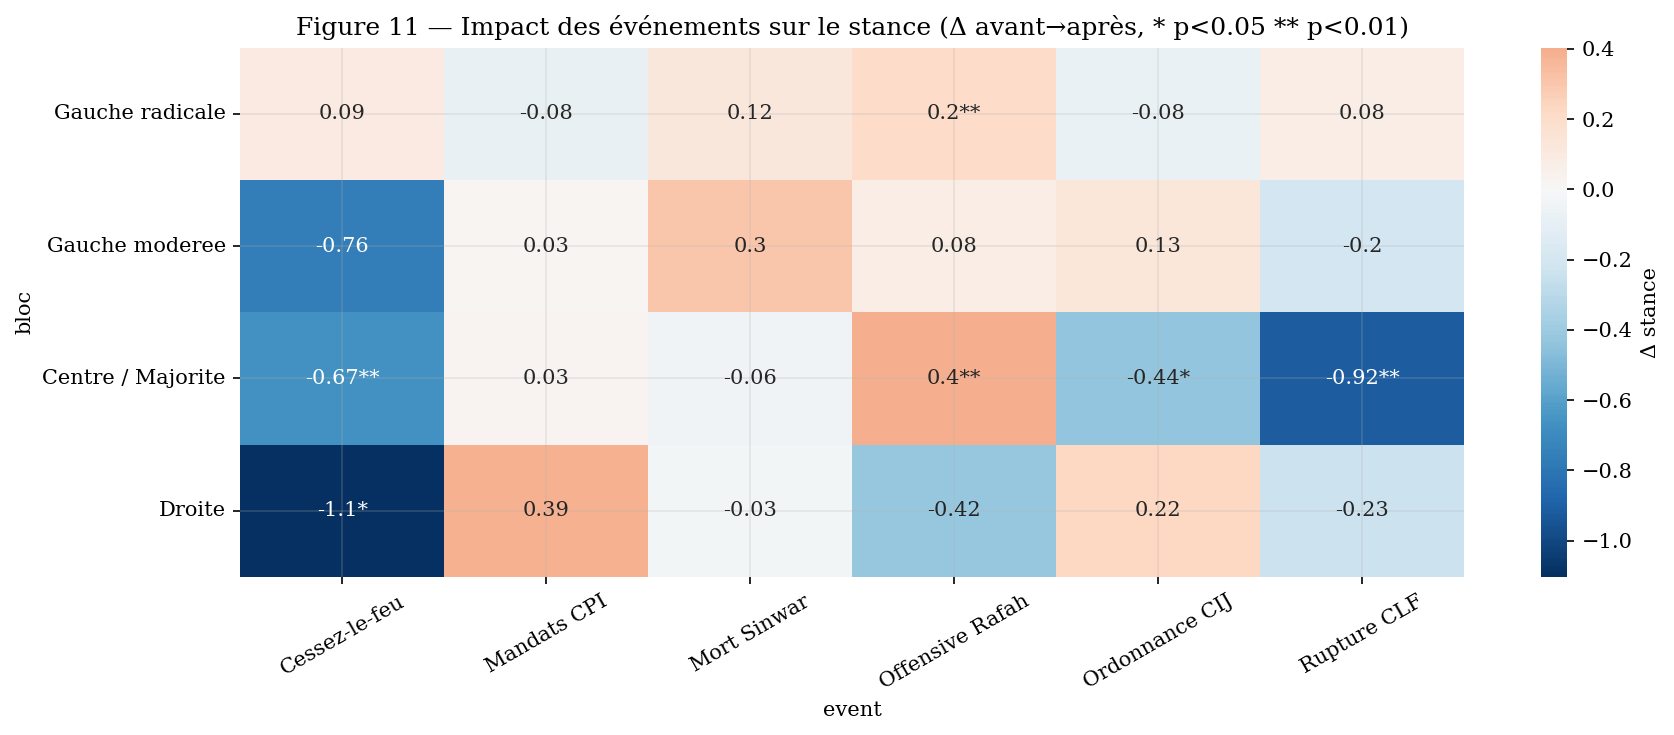

Figure 11 sauvegardée.


In [11]:
events = pd.read_csv(RESULTS_DIR / "event_impact_diff_in_diff.csv")
events_stance = events[events["variable"] == "stance_v3"].copy()

pivot_delta = events_stance.pivot(index="bloc", columns="event", values="delta")
pivot_delta = pivot_delta.reindex(BLOCS_ORDER)
pivot_sig = events_stance.pivot(index="bloc", columns="event", values="sig").reindex(BLOCS_ORDER)
annot_df = pivot_delta.round(2).astype(str).replace("nan", "")
annot_df = annot_df + pivot_sig.fillna("").astype(str).replace("nan", "")

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_delta, annot=annot_df, fmt="", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "Δ stance"})
ax.set_title("Figure 11. Impact des événements sur le stance (Δ avant→après, * p<0.05 ** p<0.01)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig11_event_impact_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 11 sauvegardée.")

In [12]:
events_stance["sig_label"] = events_stance["sig"].fillna("").astype(str).replace("nan", "")
print("Tableau détaillé des event studies (stance_v3) :")
display(events_stance[["event", "bloc", "mean_avant", "mean_apres", "delta", "p_mannwhitney", "sig_label"]].rename(columns={"sig_label": "sig"}))

Tableau détaillé des event studies (stance_v3) :


,event,bloc,mean_avant,mean_apres,delta,p_mannwhitney,sig
0,Ordonnance CIJ,Gauche radicale,1.6429,1.5658,-0.0771,0.8709,
1,Ordonnance CIJ,Gauche moderee,1.1176,1.2500,0.1324,0.4752,
2,Ordonnance CIJ,Centre / Majorite,-0.6170,-1.0526,-0.4356,0.0179,*
3,Ordonnance CIJ,Droite,-1.5000,-1.2759,0.2241,0.3194,
8,Offensive Rafah,Gauche radicale,1.6214,1.8261,0.2047,0.0009,**
9,Offensive Rafah,Gauche moderee,1.2353,1.3103,0.0751,0.7337,
10,Offensive Rafah,Centre / Majorite,-0.8837,-0.4800,0.4037,0.0075,**
11,Offensive Rafah,Droite,-1.2500,-1.6744,-0.4244,0.1382,
16,Mort Sinwar,Gauche radicale,1.6436,1.7686,0.1250,0.0646,
17,Mort Sinwar,Gauche moderee,1.2000,1.5000,0.3000,0.6195,


**Interprétation** :
- **Ordonnance CIJ** : Durcissement significatif du Centre (Δ = -0,44, p=0,018).
- **Offensive Rafah** : Durcissement Gauche radicale (Δ = +0,20, p=0,001) et convergence du Centre (Δ = +0,40, p=0,008).
- **Cessez-le-feu** : Durcissement Centre et Droite (Δ = -0,67 et -1,10, p<0,05).
- **Rupture CLF** : Durcissement du Centre (Δ = -0,92, p=0,005).

## 3.2 Tendance Mann-Kendall (stance mensuel)

In [13]:
rapport = pd.read_csv(RESULTS_DIR / "rapport_synthese.csv")
print("Résumé Mann-Kendall et tendance stance (NB3_rapport_synthese) :")
display(rapport[["bloc", "delta_stance", "mk_tau", "mk_p", "mk_trend"]])
print("\nD'après l'annexe du rapport : aucun bloc ne présente de tendance monotone significative (Mann-Kendall τ, p>0,05).")

Résumé Mann-Kendall et tendance stance (NB3_rapport_synthese) :


,bloc,delta_stance,mk_tau,mk_p,mk_trend
0,Gauche radicale,-0.0596,0.1905,0.1607,no trend
1,Gauche moderee,-1.6471,-0.1905,0.1605,no trend
2,Centre / Majorite,0.1480,0.0899,0.5144,no trend
3,Droite,-0.5533,-0.1138,0.4066,no trend



D'après l'annexe du rapport : aucun bloc ne présente de tendance monotone significative (Mann-Kendall τ, p>0,05).


## 3.3 Arc narratif et convergence

In [14]:
arc = pd.read_csv(RESULTS_DIR / "arc_narratif.csv")
synthese = pd.read_csv(RESULTS_DIR / "variables_batch_specifiques.csv")

print("Arc narratif par batch (variables clés) :")
display(arc)

conv = synthese[synthese["variable"] == "transpartisan_convergence"]
print("\nConvergence transpartisane (NEW_OFFENSIVE) par bloc :")
display(conv)

Arc narratif par batch (variables clés) :


,batch,variable,Gauche radicale,Gauche moderee,Centre / Majorite,Droite
0,CHOC,condemns_hamas_attack,11%,23%,57%,67%
1,POST_CIJ,icj_reference,39%,17%,0%,0%
2,RAFAH,icc_mention,29%,21%,9%,1%
3,POST_SINWAR,ethnic_cleansing_frame,53%,29%,0%,0%
4,MANDATS_CPI,icc_warrants_position,absent (63%),absent (45%),absent (94%),absent (83%)
5,CEASEFIRE_BREACH,two_state_mention,5%,19%,6%,1%
6,NEW_OFFENSIVE,transpartisan_convergence,7%,36%,30%,4%



Convergence transpartisane (NEW_OFFENSIVE) par bloc :


,batch,variable,bloc,pct
60,NEW_OFFENSIVE,transpartisan_convergence,Gauche radicale,6.9
61,NEW_OFFENSIVE,transpartisan_convergence,Gauche moderee,35.5
62,NEW_OFFENSIVE,transpartisan_convergence,Centre / Majorite,30.3
63,NEW_OFFENSIVE,transpartisan_convergence,Droite,3.5


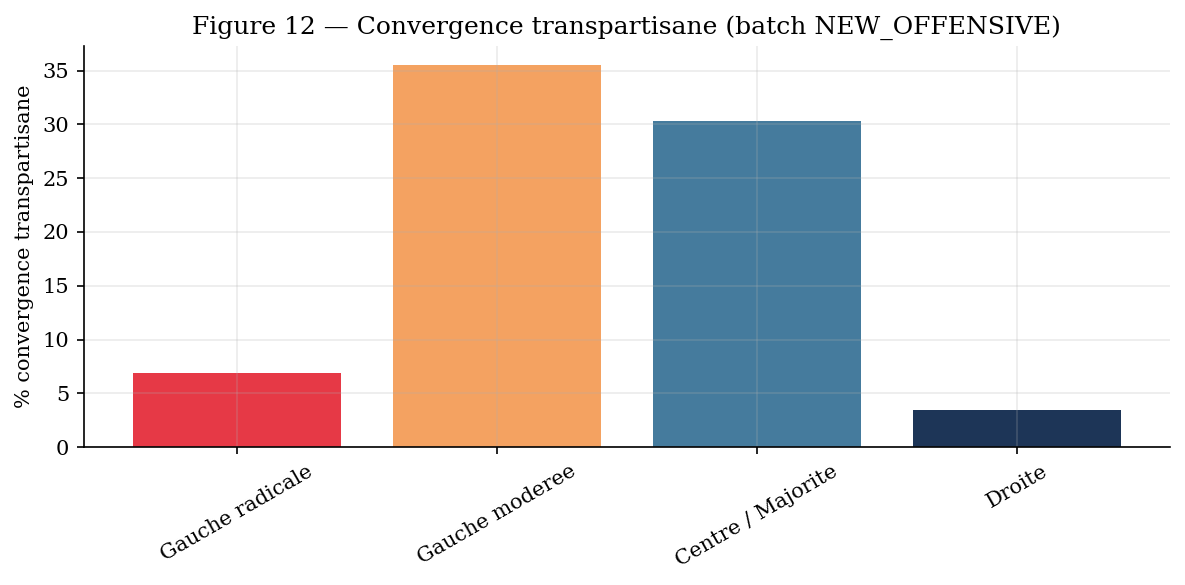

In [15]:
conv_pct = synthese[(synthese["variable"] == "transpartisan_convergence") & (synthese["batch"] == "NEW_OFFENSIVE")]
conv_pct = conv_pct.set_index("bloc").reindex(BLOCS_ORDER).reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
blocs = conv_pct["bloc"].tolist()
vals = pd.to_numeric(conv_pct["pct"], errors="coerce").fillna(0)
colors = [COLORS.get(b, "#666") for b in blocs]
ax.bar(blocs, vals, color=colors)
ax.set_ylabel("% convergence transpartisane")
ax.set_title("Figure 12. Convergence transpartisane (batch NEW_OFFENSIVE)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig12_convergence_transpartisane.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# Détection de ruptures (ruptures.Pelt)
import ruptures as rpt

cos = pd.read_csv(RESULTS_DIR / "cosine_distance_mensuelle.csv")
gd = cos[(cos["bloc1"]=="Gauche radicale") & (cos["bloc2"]=="Droite")].sort_values("month_ts")
signal = gd["cosine_dist"].values.reshape(-1, 1)
for pen in [1, 2, 3, 5]:
    algo = rpt.Pelt(model="rbf").fit(signal)
    bkps = algo.predict(pen=pen)
    print(f"pen={pen}: {len(bkps)-1} breakpoints at indices {bkps[:-1]}")

pen=1: 1 breakpoints at indices [25]
pen=2: 0 breakpoints at indices []
pen=3: 0 breakpoints at indices []
pen=5: 0 breakpoints at indices []


**Interprétation** : La convergence transpartisane est faible à gauche (7 % Gauche radicale) et à droite (4 %). Elle est plus marquée au Centre (30 %) et en Gauche modérée (36 %), suggérant que ces blocs sont plus susceptibles d'adopter un discours de convergence après la nouvelle offensive.

## 3.4 Polarisation et convergence lexicale

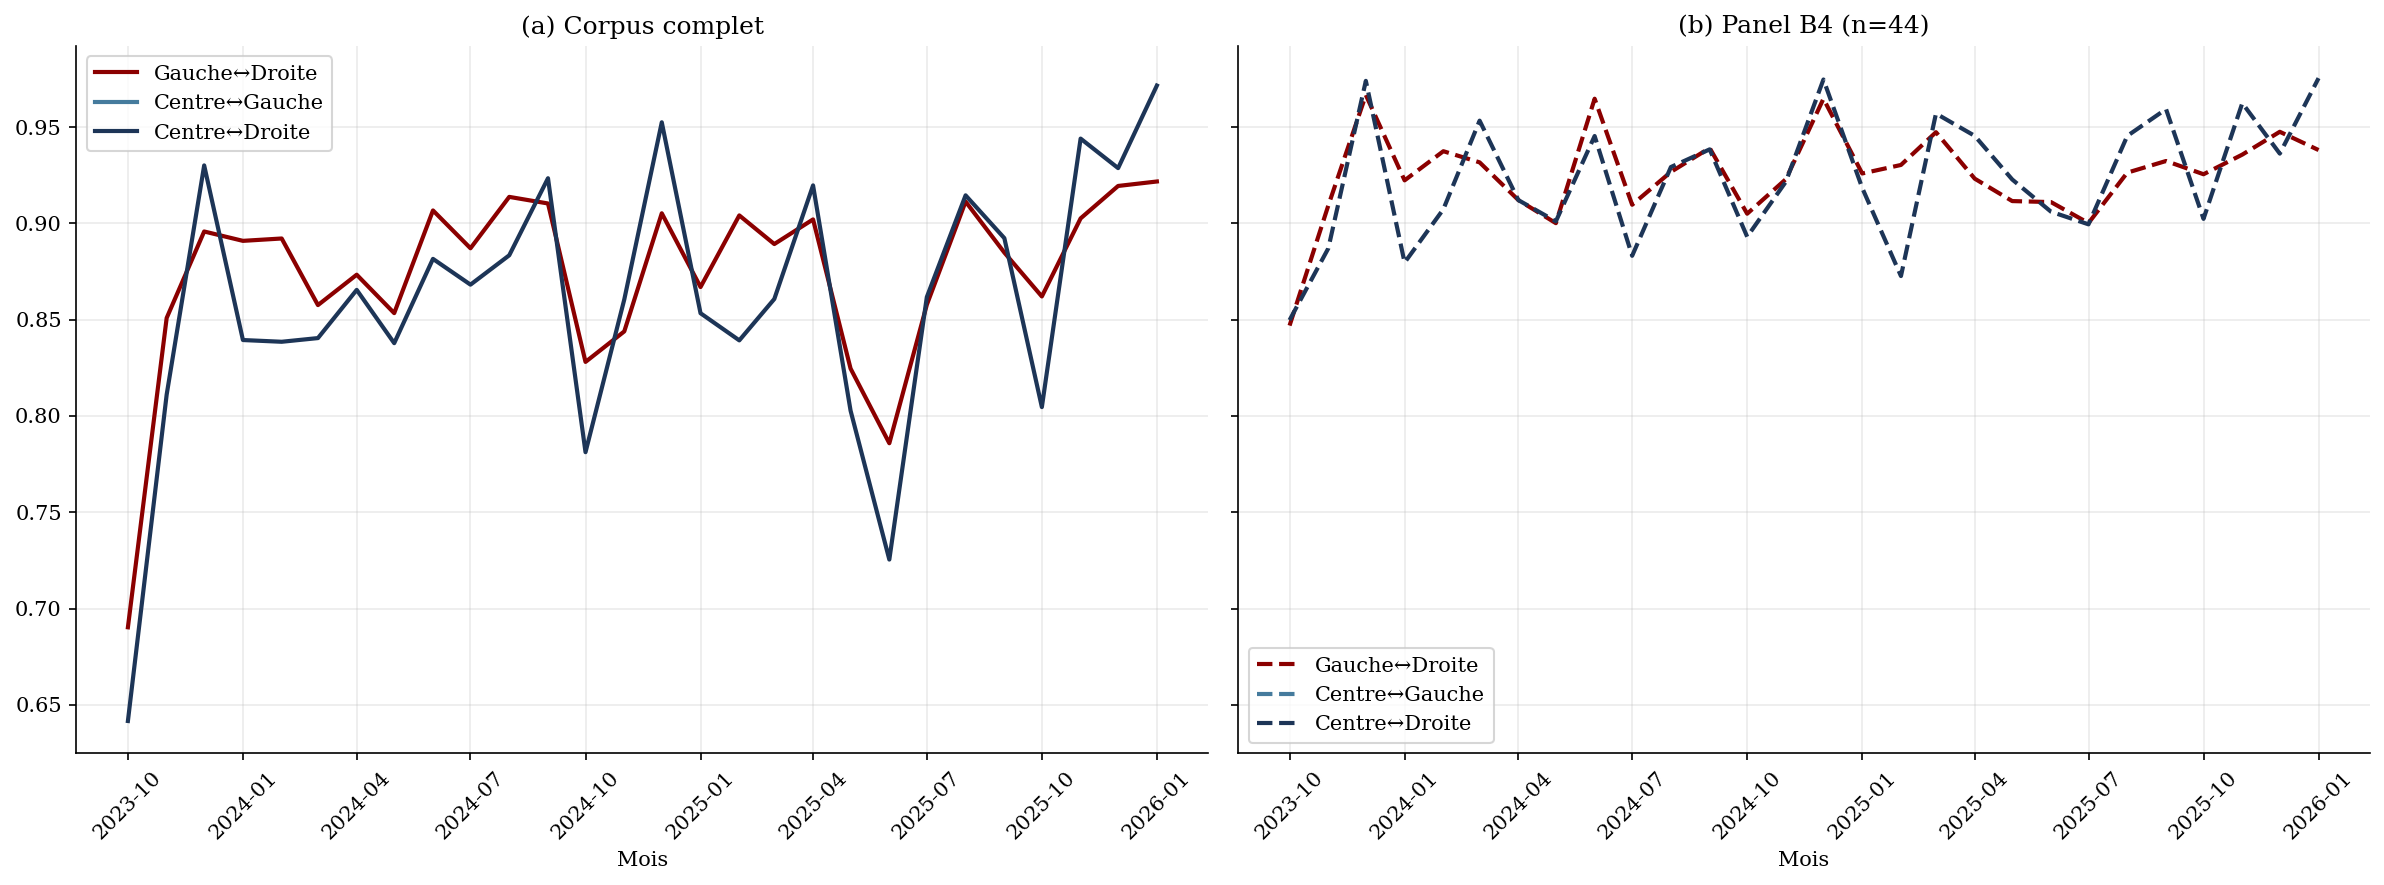

In [17]:
# Figure 13. Polarisation 3 paires (2 panels)
cos_corpus = pd.read_csv(RESULTS_DIR / "cosine_distance_mensuelle.csv")
cos_panel = pd.read_csv(RESULTS_DIR / "cosine_distance_3paires.csv")
cos_corpus["month_ts"] = pd.to_datetime(cos_corpus["month_ts"])
cos_panel["month_ts"] = pd.to_datetime(cos_panel["month_ts"])

def get_pair(df, b1, b2):
    m = df[(df["bloc1"]==b1) & (df["bloc2"]==b2)].sort_values("month_ts")
    return m["month_ts"].values, m["cosine_dist"].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
months_c = cos_corpus["month_ts"].drop_duplicates().sort_values().values

gd = cos_corpus[(cos_corpus["bloc1"]=="Gauche radicale") & (cos_corpus["bloc2"]=="Droite")].sort_values("month_ts")
cg = cos_corpus[(cos_corpus["bloc1"]=="Centre / Majorite") & (cos_corpus["bloc2"]=="Gauche radicale")].sort_values("month_ts")
cd = cos_corpus[(cos_corpus["bloc1"]=="Centre / Majorite") & (cos_corpus["bloc2"]=="Droite")].sort_values("month_ts")
ax1.plot(gd["month_ts"], gd["cosine_dist"], color="#8B0000", lw=2, label="Gauche↔Droite")
ax1.plot(cg["month_ts"], cg["cosine_dist"], color="#457B9D", lw=2, label="Centre↔Gauche")
ax1.plot(cd["month_ts"], cd["cosine_dist"], color="#1D3557", lw=2, label="Centre↔Droite")
ax1.set_title("(a) Corpus complet")
ax1.set_xlabel("Mois")
ax1.legend()
ax1.tick_params(axis="x", rotation=45)

gd = cos_panel[(cos_panel["bloc1"]=="Gauche radicale") & (cos_panel["bloc2"]=="Droite")].sort_values("month_ts")
cg = cos_panel[(cos_panel["bloc1"]=="Centre / Majorite") & (cos_panel["bloc2"]=="Gauche radicale")].sort_values("month_ts")
cd = cos_panel[(cos_panel["bloc1"]=="Centre / Majorite") & (cos_panel["bloc2"]=="Droite")].sort_values("month_ts")
ax2.plot(gd["month_ts"], gd["cosine_dist"], color="#8B0000", lw=2, ls="--", label="Gauche↔Droite")
ax2.plot(cg["month_ts"], cg["cosine_dist"], color="#457B9D", lw=2, ls="--", label="Centre↔Gauche")
ax2.plot(cd["month_ts"], cd["cosine_dist"], color="#1D3557", lw=2, ls="--", label="Centre↔Droite")
ax2.set_title("(b) Panel B4 (n=44)")
ax2.set_xlabel("Mois")
ax2.legend()
ax2.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig13_polarisation_3paires.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.5 Analyses v4 étendues : cohérence Twitter/AN, cibles, demandes, conditionnalité

Les CSV étendus (`coherence_twitter_an_par_depute`, `target_primary_par_batch_bloc`, `key_demands_par_batch_bloc`, `conditionality_par_batch_bloc`) exploitent le corpus v4 (fenêtres événementielles) pour affiner les analyses par batch et par bloc.

In [ ]:
from config import BATCH_ORDER, BLOC_ORDER

coh = pd.read_csv(RESULTS_DIR / "coherence_twitter_an_par_depute.csv")
if len(coh) > 0:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(coh["stance_mean_Twitter"], coh["stance_mean_AN"], c=coh["bloc"].map(COLORS), alpha=0.7, s=30)
    lims = [-2.5, 2.5]
    ax.plot(lims, lims, "k--", lw=1, label="Identité (Twitter = AN)")
    ax.set_xlabel("Stance moyen Twitter"); ax.set_ylabel("Stance moyen AN")
    ax.set_title("Cohérence Twitter / AN par député (n≥2 chacun)")
    for b in BLOC_ORDER:
        if (coh["bloc"] == b).any():
            ax.scatter([], [], c=COLORS[b], label=b, s=50)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_xlim(lims); ax.set_ylim(lims)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig_coherence_twitter_an.png", dpi=150, bbox_inches="tight")
    plt.show()
    display(coh[["author", "bloc", "stance_mean_Twitter", "stance_mean_AN", "abs_delta"]].head(10))
else:
    print("Pas assez de députés avec Twitter + AN (n≥2 chacun) pour la cohérence.")

In [ ]:
target_batch = pd.read_csv(RESULTS_DIR / "target_primary_par_batch_bloc.csv")
cond_batch = pd.read_csv(RESULTS_DIR / "conditionality_par_batch_bloc.csv")
demands_batch = pd.read_csv(RESULTS_DIR / "key_demands_par_batch_bloc.csv")

# Top cibles par bloc (agrégé sur batches) : ex. Hamas, Israel, France
target_bloc = pd.read_csv(RESULTS_DIR / "target_primary_par_bloc.csv")
top_targets = target_bloc.groupby("bloc").apply(lambda g: g.nlargest(3, "pct")).reset_index(drop=True)
display(top_targets[["bloc", "target_primary", "pct"]])

# Conditionnalité du CF par batch : Droite vs Gauche radicale
cond_pivot = cond_batch.pivot_table(index="batch", columns="bloc", values="pct", aggfunc="first")
cond_droite = cond_batch[cond_batch["bloc"] == "Droite"].set_index("batch")
cond_gr = cond_batch[(cond_batch["bloc"] == "Gauche radicale") & (cond_batch["conditionality"] == "absolute")]
print("\nDroite : part 'absolute' (CF sans condition) par batch")
display(cond_droite[["conditionality", "pct"]].head())

## 3.6 Cas négatif : la Droite au cessez-le-feu

La Droite constitue un cas négatif : faible adoption du lexique du cessez-le-feu, stance stable pro-Israël. Les CSV `droite_stance_par_batch` et `droite_stance_mensuel` documentent cette stabilité.

In [ ]:
droite_batch = pd.read_csv(RESULTS_DIR / "droite_stance_par_batch.csv")
droite_mensuel = pd.read_csv(RESULTS_DIR / "droite_stance_mensuel.csv")
droite_mensuel["date"] = pd.to_datetime(droite_mensuel["date"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
batch_order = [b for b in BATCH_ORDER if b in droite_batch["batch"].values]
x = np.arange(len(batch_order))
axes[0].bar(x, droite_batch.set_index("batch").reindex(batch_order)["stance_mean"].values, color="#1D3557")
axes[0].set_xticks(x)
axes[0].set_xticklabels(batch_order, rotation=45, ha="right")
axes[0].set_ylabel("Stance moyen")
axes[0].set_title("(a) Droite : stance par batch")
axes[0].axhline(0, color="gray", ls="--", lw=0.8)

axes[1].plot(droite_mensuel["date"], droite_mensuel["stance_mean"], color="#1D3557", lw=2)
axes[1].fill_between(droite_mensuel["date"], droite_mensuel["stance_mean"], alpha=0.3, color="#1D3557")
axes[1].set_ylabel("Stance moyen"); axes[1].set_xlabel("Mois")
axes[1].set_title("(b) Droite : évolution mensuelle")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_droite_stance_batch_mensuel.png", dpi=150, bbox_inches="tight")
plt.show()
print("La Droite reste pro-Israël tout au long de la période. Aucune convergence vers le lexique du cessez-le-feu.")

## Key Findings

- **Polarisation** : G.rad ↔ Droite = distance maximale ; Centre se rapproche de G.rad (pivot) après Rafah et CPI.
- **Event impact** : CIJ → Centre durcit (p=0,018) ; Rafah → G.rad durcit (p=0,001), Centre converge (p=0,008) ; CF → Centre et Droite durcissent ; Rupture CLF → Centre durcit (p=0,005).
- **Convergence** : G.mod 35,5 %, Centre 30,3 % à NEW_OFFENSIVE.
- **Régression** : Bloc et batch expliquent une part significative de la variance du stance ; interactions bloc×batch captent les event impacts nets.

## Discussion littérature

Le Centre comme weathervane, sensible aux événements juridiques internationaux (CIJ, CPI) plus qu'aux événements militaires - est cohérent avec Suter et al. (2025, Policy & Internet). La convergence transpartisane tardive pourrait refléter un « depolarization event » (Morales et al. 2024, EPJ Data Science). Le décalage entre position implicite (ceasefire_call LLM) et vocabulaire explicite (ceasefire_lexical regex) chez la Droite illustre la distinction du framework DALiSM (ACM WebSci 2025).

## Limites

- Pas de validation humaine de l'annotation LLM.
- Variables batch-spécifiques à 100 % (genocide_framing, rafah_reaction) = artefacts, pas des résultats.
- Pas de causalité stricte : « associé à », « coïncide avec », jamais « causé par ».
- Panel B4 non représentatif (75 % G.rad).
- Mann-Kendall non significatif = pas de trend monotone, pas absence de changement.